# Code Assignment 5: Heat


(YOUR NAME HERE)

(TODAY'S DATE HERE)

## Part 1: Temperature profiles in permafrost

You have obtained two CSV-format files containing measurements of ground temperature as a function of depth in a borehole drilled near Tulik Lake, Alaska. The files are:

- `TUL_81AUG24.csv` - data from August, 1981
- `TUL_14JUL02.csv` - data from July, 2014

Depth values are in meters below the ground surface, and temperature values are in degrees C.

Write a program to read the contents of both files and plot them. Features of your plot should include:

- The x-axis on your plot should be temperature and the y-axis should be depth.
- Depth should start at zero at the top of the graph, and increase below it.
- Use different colors for the two dates.
- Provide a legend showing which is which.

Hint: to invert the y-axis, you could set the y-axis limits to go from high to low (e.g., `plt.ylim([maxdepth, mindepth])`), or you could use `plt.gca().invert_yaxis()`.

## Part 2: Fitting the geotherm

Below a certain depth, your data reveal a linear increase in temperature with depth. The rate of increase in temperature with depth is called the *geothermal gradient*, or simply the *geotherm*. Your job is to estimate the geotherm from the 2014 data.

### How to use the `polyfit()` function

To do this, you will use the numpy `polyfit()` function. This fits a polynomial to a given set of (x, y) data. Here you want a polynomial of degree 1, which is a straight line. `polyfit()` takes 3 arguments: the $x$ values, the $y$ values, and the polynomial degree (again, set this to 1). It returns the best-fit parameters as a tuple. For example, if you have arrays of data called `x` and `y`, then running this line:

```
p = np.polyfit(x, y, 1)
```
will return a 2-element tuple in which `p[0]` is the best-fit slope and `p[1]` is the best-fit intercept (in other words, the function finds the parameters for the best-fitting line `y = p[0] x + p[1]`).

See [here](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) for the function documentation.

### Your tasks

Notice that the upper portion of your temperature data appears to be curved, as if the surface had recently warmed and the ground below it had warmed in response. Here, you're interested in the linear portion of the geotherm below this curve. Tasks:

- Extract from your 2014 data the portion that appears linear.
- Use the `polyfit()` function on this portion of the data to identify a best-fit slope and intercept.
- The best-fit slope represents the geotherm, in degrees per meter. Convert this to degrees per kilometer, and print out the value.


## Part 3: Calculating and plotting heat flow

### Part 3a: the deep geotherm

The *geothermal heat flow* is the rate at which heat is carried upward by conduction. According to **Fourier's law**, the heat flow depends on the geothermal gradient, which we'll represent with the symbol $\Gamma$, and on a material property called the *thermal conductivity*, which we'll represent with the symbol $k$:
$$
\text{heat flow} = -k \Gamma
$$
As a rough estimate for cold-region soil, assume that the thermal conductivity $k$ is 1 Watt per meter per degree C.

- Using this value, and the geothermal gradient you obtained in Part 2, calculate and print out the geothermal heat flow (including its units).

- Write down a comment on how this heat flow from underground toward the surface compares with the radiant heat flow from the sun, which for the Arctic is roughly [100 Watts per square meter](https://en.wikipedia.org/wiki/Solar_irradiance#/media/File:Insolation.png).


The solar heat flow is roughly 2500 times the geothermal heat flow.

### Part 3b: variations in heat flow

In the data from Alaska, the geothermal gradient actually varies with depth. Your next task is to explore those variations and their implications for heat flow.

The temperature gradient between any two points can be calculated from: $\Delta T / \Delta z$, where $\Delta z$ is the distance between the points (i.e., the difference in depth between them), and $\Delta T$ is their difference in temperature.

- Use the numpy function `diff()` to calculate the difference in depth between each successive pair of data points.
- Use `diff()` to calculate the difference in *temperature* between each pair of points.
- Now divide the temperature difference by the depth difference to get the geothermal gradient at each point.
- Plot the resulting point-wise geothermal gradient against depth (note: watch out for an array mismatch! Hint: skip either the first or last depth value when plotting; e.g., `depth[1:]` or `depth[:-1]`; if you get stuck on this, ask me in class or office hours!)
- Include a **grid** in your plot (e.g., `plt.grid(True)`)
- Wherever your gradient is *positive* (temperature increasing with depth), heat should be flowing upward toward the surface. Wherever it is *negative*, heat should be flowing down into the ground. Write down your observations about the direction of heat flow at different depths in the profile.


The gradient is positive below about 60 meters. It is negative above this, indicating downward heat flow.

## Part 4: temperature of a cubesat

Heat (thermal energy) can be transported by conduction (as in permafrost), convection (as in a cold wind), or radiation (as in sunlight or blackbody radiation). Here you will construct a numerical model for the temperature evolution of a small object in orbit around the earth and the sun.

A Cubesat is a cube-shaped satellite that can be as small as 10 cm (0.1 m) on a side. Before launching a 0.1 m diameter cubesat, we want to make sure it won't either overheat or freeze. To do so, we have to estimate its temperature.

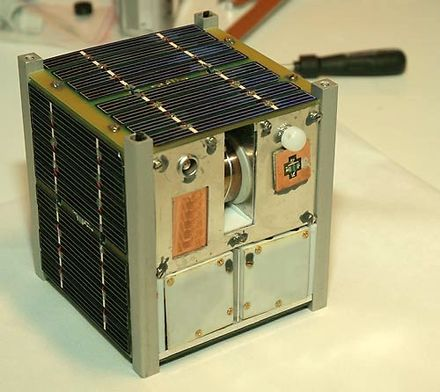

The following a differential equation model for the rate of change of its temperature, $T$, as a function of solar radiation (on one face) and radiative cooling:

$$\frac{dT}{dt} = \frac{S_0 (1-a)}{2b} - \frac{6 \epsilon \sigma T^4}{b}$$

where:

$t =$ time

$b = W\rho C_p$

$W =$ width of the cubesat, m (say 0.1)

$\rho = $ density of the cubesat, kg/m$^3$ (say 2000)
  
$C_p = $ specific heat of the cubesat, J/kg K (say 500)

$S_0 = $ solar irradiance, W/m$^2$ (1365)

$a = $ cubesat's albedo

$\epsilon =$ IR emissivity (here assume 0.25)

$\sigma = $ Stefan-Boltzmann constant, W / m$^2$ K$^4$ ($5.67\times 10^{-8}$)

The first term on the right represents the input of energy from sunlight shining on the satellite. The second represents the loss of energy by radiation to space. These are the same terms that show up in the planetary energy balance we looked at earlier in the semester.

### Part 4a: steady solution

Explore the steady solution---that is, the temperature when the inflow and outflow of heat energy are in perfect balance.

1. Solve the equation for temperature, $T$, when $dT/dt = 0$.
2. Write code to calculate how the steady temperature, $T$, varies with the cubesat's albedo, from 0 (painted black) to 1 (painted reflective white).

(Note: this is a highly simplified model that ignores infrared heating from the earth, cooling when the sat is in the earth's shadow, heat generated inside the sat by its electronics, etc...)

$$
T = \sqrt[4]{S_0 (1 - a)}{12 \epsilon \sigma}
$$

### Part 4b: time-dependent temperature change

Using a forward-difference approximation, here's our numerical approximation equation:

$$T_{t+1} = T_t + \Delta t \left(\frac{S_0 (1-a)}{2b} - \frac{6 \sigma T_t^4}{b}\right)$$

Write a program to implement an iterative solution to this equation (for a fixed albedo). Verify that your time-dependent solution approaches the steady solution over time. How long does the cubesat take to reach its steady equilibrium temperature?

## Optional bonus-point problem #1

Some of earth's internal heat comes from radioactive decay. But for the sake of an exercise, let's consider a decay that's not so important for heat production but has become quite important for measuring erosion at the earth's surface.

An atom of Beryllium-10 is produced when a high-energy neutron produced by cosmic rays strikes an oxygen nucleus. When a bare bedrock surface containing quartz is exposed to the atmosphere, Beryllium-10 will build up over time at a rate $P_0$ that depends on latitude and altitude. Let's assume for now that $P_0 = 10$ atoms per gram of quartz per year. Beryllium-10 is a radioisotope that decays with a half life of about 1.4 million years. The equation for the concentration of Beryllium-10 in a quartz grain at the earth's surface is:

$$\frac{dC}{dt} = P_0 - \lambda C$$

where $\lambda \approx 5\times 10^{-7}$ is the decay constant.

Write down the math for a finite-difference approximation to this equation (hint: it will look very similar to the finite-difference equation for the Cubesat temperature).

## Optional bonus-point problem #2

Using the above finite-difference scheme, write a program to calculate and plot the concentration of Beryllium-10 over time, starting from zero concentration. What would the concentration be for a quartz grain in a glacial boulder that has been exposed to air for the last 16,000 years?

## Optional bonus-point problem #3

Use your code to estimate how long it takes to get 95% of the way to secular equilibrium.